  command   val
0    find  5520
1    echo   189
2     cat   128
3   mkdir   125
4   chown   109
5      ls   104
6   rsync    88
7    grep    70
8    read    69
9      ln    62
Length of augmented training set: 57636
Length of part augment training set: 33734
Length of original training set: 8159


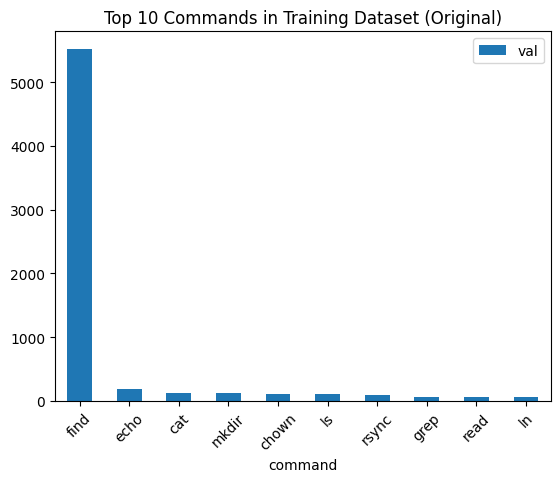

In [60]:
import pandas as pd
# from datasets import Dataset
import matplotlib.pyplot as plt
import numpy as np


with open("dataset_postprocessed/train.nl.filtered", "r") as f:
    nl_lines = f.read().splitlines()
        
with open("dataset_postprocessed/train.cm.filtered", "r") as f:
    bash_lines = f.read().splitlines()


with open("dataset_postprocessed/generated_400.nl", "r") as f:
    nl_lines_generated = [i.removesuffix(".") for i in f.read().splitlines()]
        
with open("dataset_postprocessed/generated_400.cm", "r") as f:
    bash_lines_generated = f.read().splitlines()

with open("dataset_postprocessed/generated_400_1.nl", "r") as f:
    nl_lines_generated_1 = [i.removesuffix(".") for i in f.read().splitlines()]
        
with open("dataset_postprocessed/generated_400_1.cm", "r") as f:
    bash_lines_generated_1 = f.read().splitlines()


train_dataset = {
    "nl": nl_lines_generated + nl_lines_generated_1,
    "bash": bash_lines_generated + bash_lines_generated_1
}

df = pd.DataFrame(train_dataset)

df["root_cmd"] = df["bash"].apply(lambda x: x.split()[0] if isinstance(x, str) and len(x.split()) > 0 else "unknown")

df1 = pd.DataFrame({"bash": bash_lines, "nl": nl_lines})
df1["root_cmd"] = df1["bash"].apply(lambda x: x.split()[0] if isinstance(x, str) and len(x.split()) > 0 else "unknown")
d = df1["root_cmd"].value_counts().reset_index().head(10)
d.columns = ["command", "val"]
ax = d.plot.bar(x="command", y="val", rot=45, title="Top 10 Commands in Training Dataset (Original)")
print(d)
len(df1)

print(f"Length of augmented training set: {len(df) + len(df1)}")
print(f"Length of part augment training set: {len(bash_lines) + len(nl_lines_generated)}")
print(f"Length of original training set: {len(df1)}")
# print(df["root_cmd"].nunique())

In [ ]:
df_counts = df["root_cmd"].value_counts().reset_index()
df1_counts = df1["root_cmd"].value_counts().reset_index()
df_counts["dataset"] = "augmented"
df1_counts["dataset"] = "original"

merged_counts = pd.merge(
    df1_counts, 
    df_counts, 
    on = "root_cmd", 
    how = "outer", 
    suffixes = ("_original", "_augmented")
)

merged_counts = merged_counts.fillna(0)
merged_counts["total_count"] = merged_counts["count_original"] + merged_counts["count_augmented"]
merged_counts.sort_values(by="total_count", ascending = False, inplace = True)
merged_counts = merged_counts.reset_index(drop = True)
merged_counts['log_original'] = np.log10(merged_counts['count_original'])
merged_counts['log_augmented'] = np.log10(merged_counts['count_augmented'])
merged_counts = merged_counts.head(100) 
print(merged_counts.head())

  root_cmd  count_original dataset_original  count_augmented  \
0     find          5520.0         original             62.0   
1    which            19.0         original           1096.0   
2      cat           128.0         original            949.0   
3   finger             8.0         original            958.0   
4       ls           104.0         original            850.0   

  dataset_augmented  total_count  log_original  log_augmented  
0         augmented       5582.0      3.741939       1.792392  
1         augmented       1115.0      1.278754       3.039811  
2         augmented       1077.0      2.107210       2.977266  
3         augmented        966.0      0.903090       2.981366  
4         augmented        954.0      2.017033       2.929419  


c:\Users\Steam\miniconda3\envs\ece228\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Steam\miniconda3\envs\ece228\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


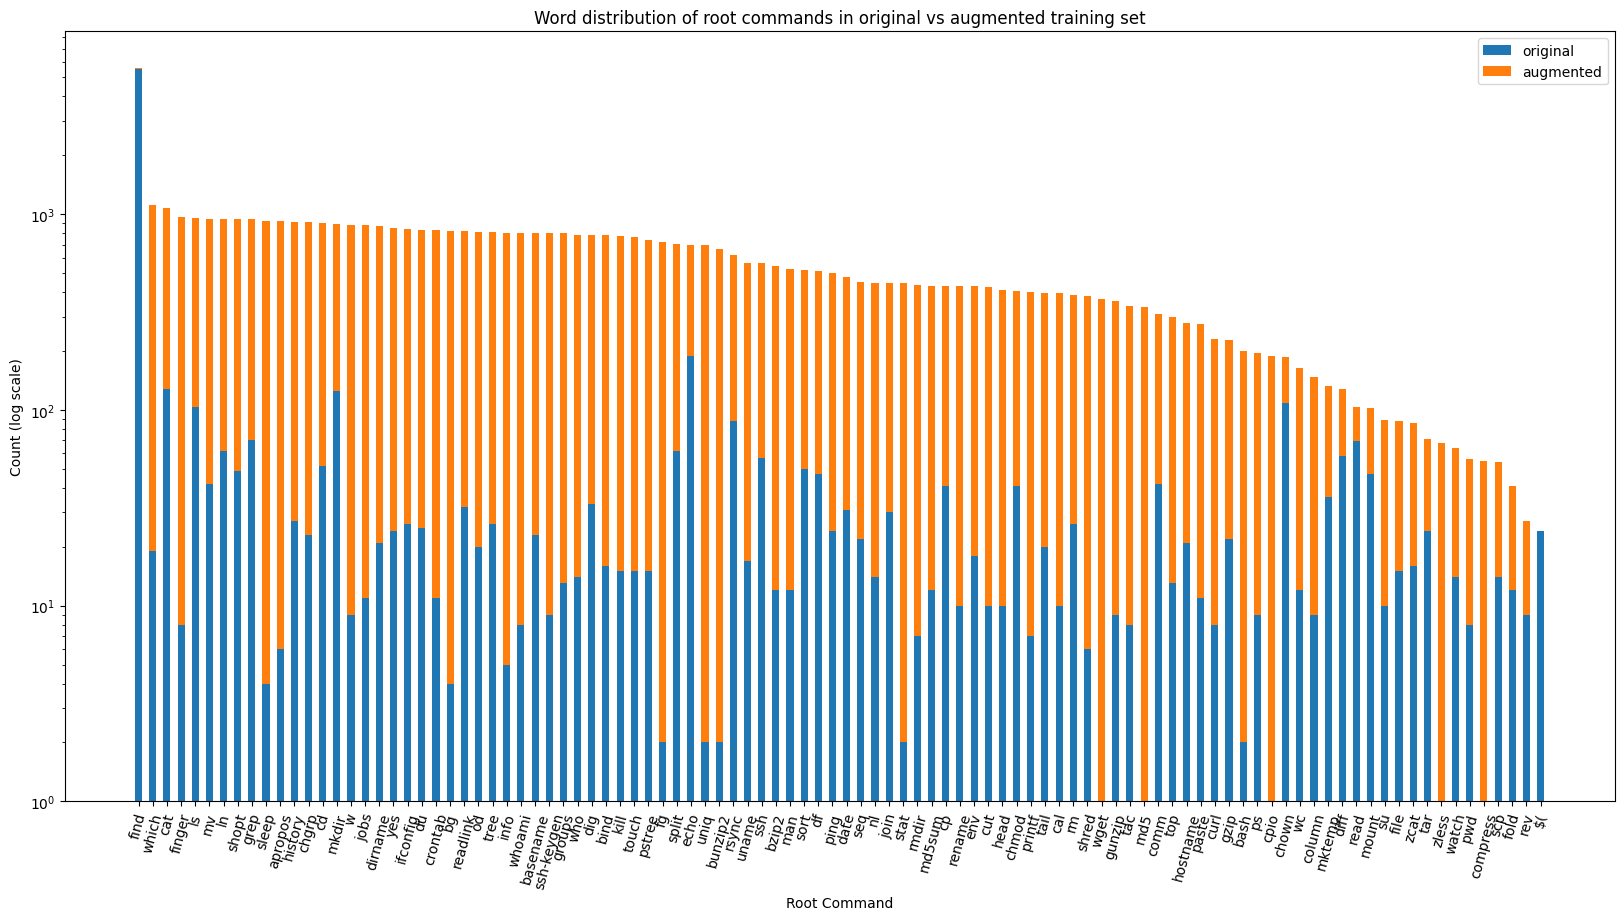

In [ ]:
# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_stacked.html

fig, ax = plt.subplots(figsize=(20, 10))
bottom = np.zeros(3)
width = 0.5
#@for boolean, weight_count in weight_counts.items():
p = ax.bar(merged_counts["root_cmd"], merged_counts["count_original"], width, label = "original")
bottom = np.array(merged_counts["count_original"].values)

p = ax.bar(merged_counts["root_cmd"], merged_counts["count_augmented"], width, label = "augmented", 
    bottom=bottom)
bottom += merged_counts["count_augmented"].values

ax.set_yscale("log")
ax.tick_params("x", rotation=75)
ax.set_ylabel("Count (log scale)")
ax.set_xlabel("Root Command")

ax.set_title("Word distribution of root commands in original vs augmented training set")
ax.legend(loc="upper right")

plt.show()

[0.05609986881410345, 0.1121997376282069, 0.16829960644231035, 0.2243994752564138, 0.28049934407051724, 0.3365992128846207, 0.39269908169872414, 0.4487989505128276, 0.504898819326931, 0.5609986881410345, 0.6170985569551379, 0.6731984257692414, 0.7292982945833448, 0.7853981633974483, 0.8414980322115517, 0.8975979010256552, 0.9536977698397586, 1.009797638653862, 1.0658975074679655, 1.121997376282069, 1.1780972450961724, 1.2341971139102759, 1.2902969827243793, 1.3463968515384828, 1.4024967203525862, 1.4585965891666897, 1.514696457980793, 1.5707963267948966, 1.626896195609, 1.6829960644231035, 1.739095933237207, 1.7951958020513104, 1.8512956708654138, 1.9073955396795172, 1.9634954084936207, 2.019595277307724, 2.0756951461218276, 2.131795014935931, 2.1878948837500345, 2.243994752564138, 2.3000946213782414, 2.356194490192345, 2.4122943590064483, 2.4683942278205517, 2.524494096634655, 2.5805939654487586, 2.636693834262862, 2.6927937030769655, 2.748893571891069, 2.8049934407051724, 2.861093309

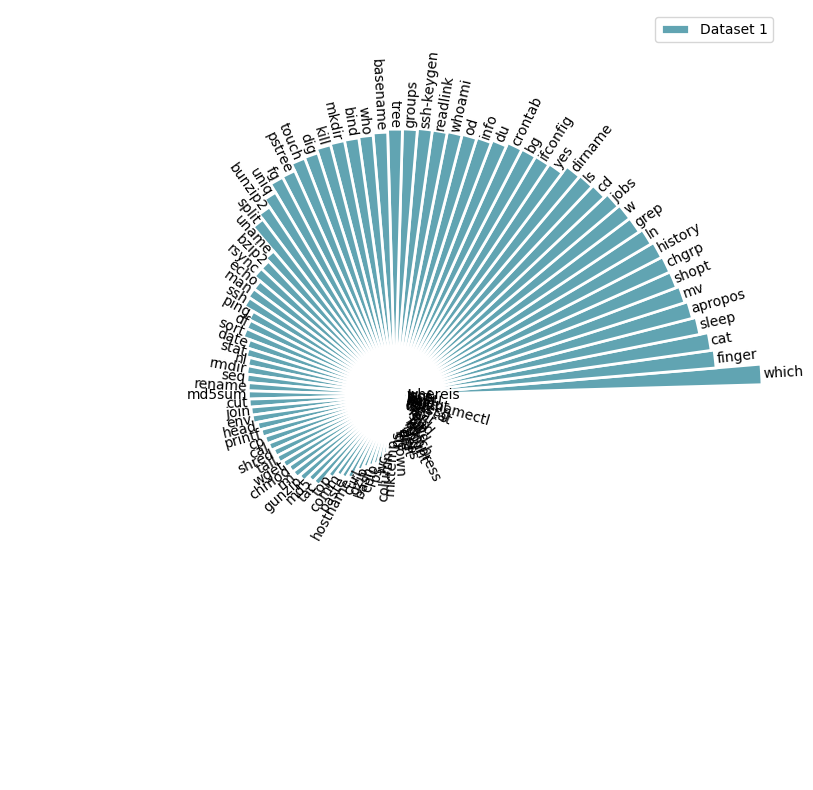

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# https://python-graph-gallery.com/circular-barplot-basic/

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
plt.axis('off')

lowerLimit = 30  
upperLimit = 100 
d_max = df1_counts['count'].max()

# compute coordinates
slope = (d_max - lowerLimit) / d_max
heights = slope * df1_counts['count']
width = 2 * np.pi / len(df1_counts.index)

indexes = list(range(1, len(df1_counts.index) + 1))
angles = [element * width for element in indexes]

# print(angles)

bars = ax.bar(
    x = angles, 
    height = heights, 
    width = width, 
    bottom = lowerLimit, 
    linewidth = 2,
    edgecolor = "white",
    color = "#61a4b2", 
    label = "Dataset 1"
)

labelPadding = 4

for bar, angle, height, label in zip(bars,angles, heights, df1_counts["root_cmd"]):

    # Labels are rotated. Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle)

    # Flip some labels upside down
    alignment = ""
    if angle >= np.pi/2 and angle < 3*np.pi/2:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"

    # Finally add the labels
    ax.text(
        x=angle, 
        y=lowerLimit + bar.get_height() + labelPadding, 
        s=label, 
        ha=alignment, 
        va='center', 
        rotation=rotation, 
        rotation_mode="anchor") 
    
plt.legend(loc="upper right")
plt.show()